# Phase 1: Biomechanical Data Exploration

## Project: OrthoAnalytics - Clinical Gait Study

This notebook covers the initial exploration of the **Enhanced Gait Biomechanics Dataset**:
1. **Data Ingestion**: Loading the gait cycle data.
2. **Data Structure**: Understanding the conditions (Unbraced, Knee-Braced, Ankle-Braced) and joints.
3. **Gait Visualization**: Plotting joint angles across the normalized stride (0-100%).
4. **Impact of Orthopedic Braces**: Comparing kinematics across conditions.
5. **Quantitative Analysis**: Range of Motion (ROM) assessment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

### 1. Data Ingestion
We load the real biomechanical data from the UCI Repository.

In [2]:
data_path = "../data/raw/gait.csv"
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (181800, 7)


,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399


### 2. Metadata Mapping
According to the dataset documentation:
- **Condition**: 1=Unbraced, 2=Knee-Braced, 3=Ankle-Braced
- **Joint**: 1=Ankle, 2=Knee, 3=Hip
- **Leg**: 1=Left, 2=Right
- **Time**: Normalized 0-100 (percentage of gait cycle)

In [3]:
condition_map = {1: 'Unbraced', 2: 'Knee-Braced', 3: 'Ankle-Braced'}
joint_map = {1: 'Ankle', 2: 'Knee', 3: 'Hip'}
leg_map = {1: 'Left', 2: 'Right'}

df['condition_name'] = df['condition'].map(condition_map)
df['joint_name'] = df['joint'].map(joint_map)
df['leg_name'] = df['leg'].map(leg_map)

### 3. Visualizing a Single Subject Baseline (Unbraced)
Let's look at the baseline gait of Subject 1.

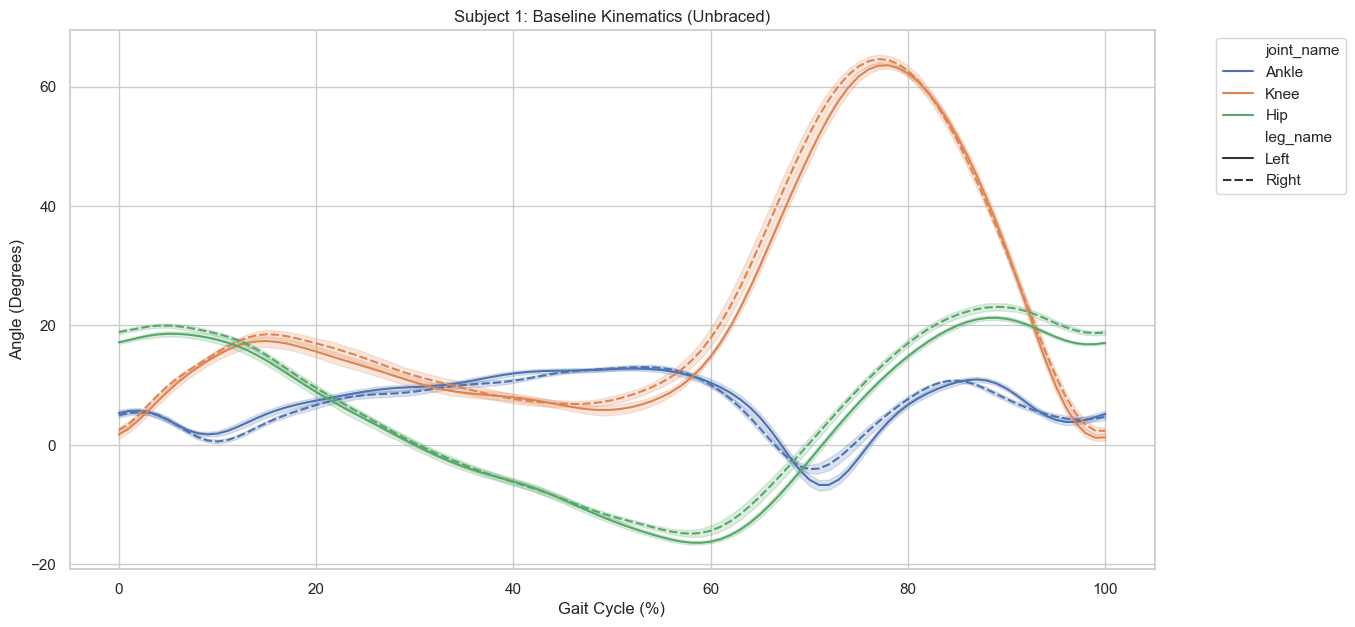

In [4]:
subj1_unbraced = df[(df['subject'] == 1) & (df['condition'] == 1)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=subj1_unbraced, x='time', y='angle', hue='joint_name', style='leg_name')
plt.title('Subject 1: Baseline Kinematics (Unbraced)')
plt.xlabel('Gait Cycle (%)')
plt.ylabel('Angle (Degrees)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 4. Impact of Orthopedic Braces
We compare the Knee and Ankle brace conditions against the baseline for the Right leg (the braced limb).

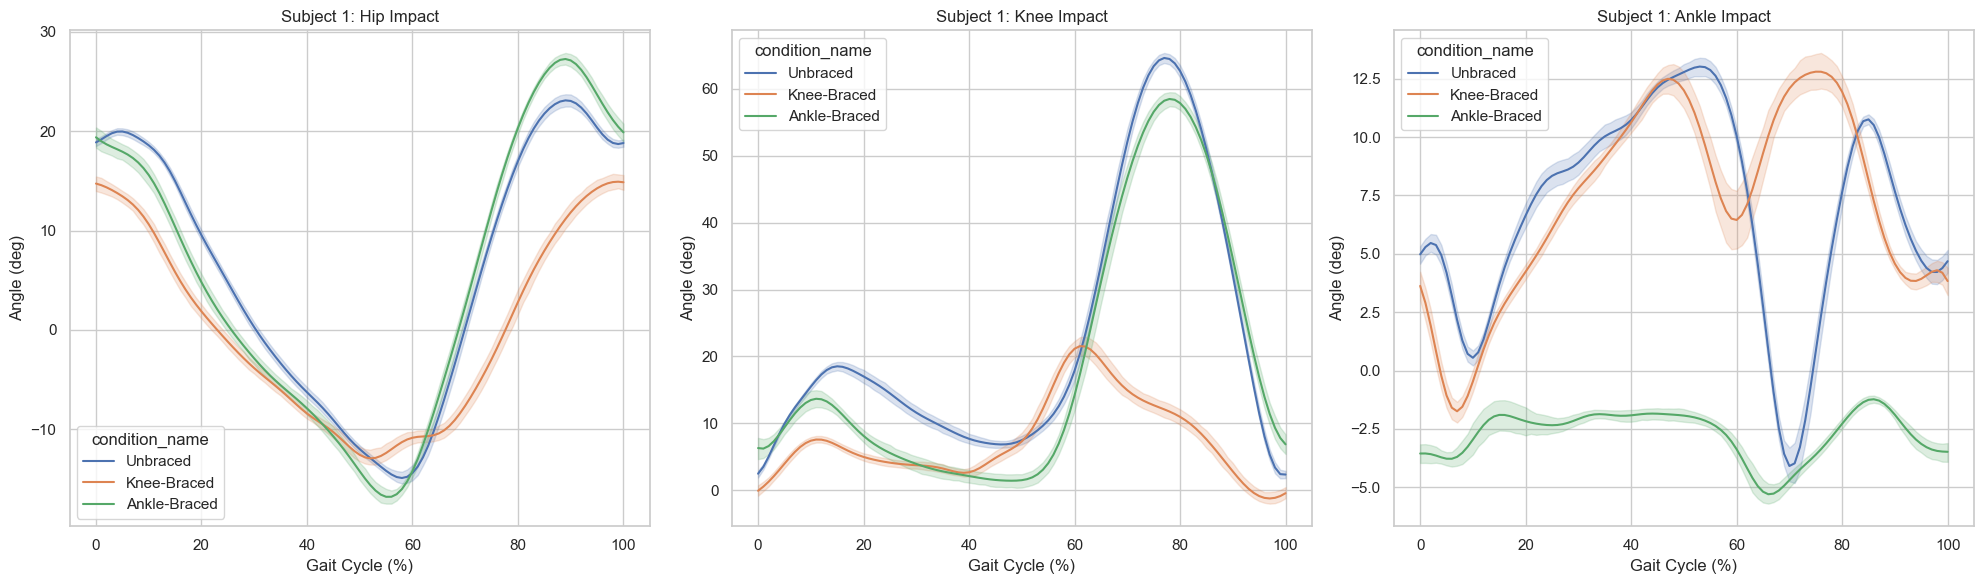

In [5]:
right_leg_data = df[(df['subject'] == 1) & (df['leg'] == 2)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

for i, joint in enumerate(['Hip', 'Knee', 'Ankle']):
    sns.lineplot(data=right_leg_data[right_leg_data['joint_name'] == joint], 
                 x='time', y='angle', hue='condition_name', ax=axes[i])
    axes[i].set_title(f'Subject 1: {joint} Impact')
    axes[i].set_xlabel('Gait Cycle (%)')
    axes[i].set_ylabel('Angle (deg)')

plt.tight_layout()
plt.show()

### 5. Quantitative Analysis: Range of Motion (ROM)
ROM is calculated as $\max(angle) - \min(angle)$ across the stride.

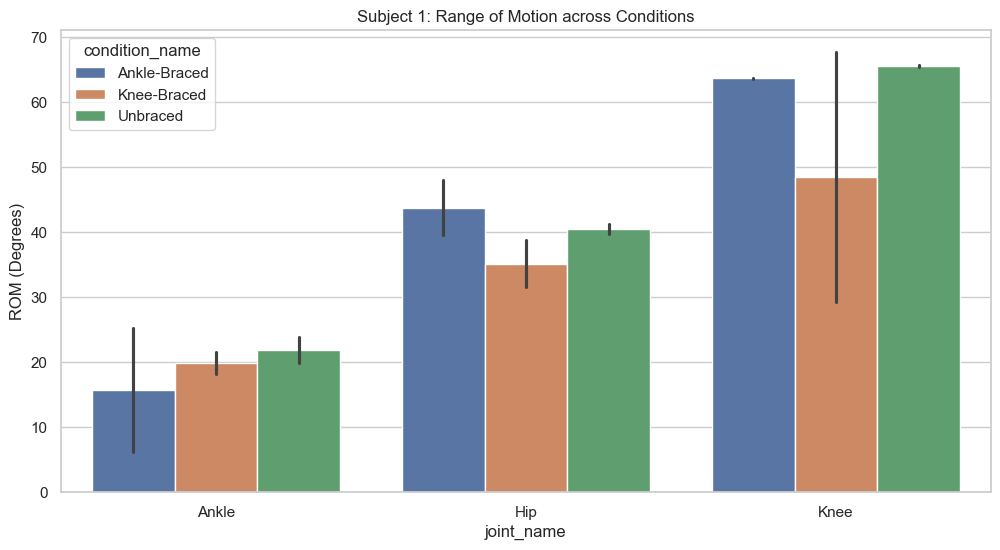

Mean ROM across all subjects:


joint_name,Ankle,Hip,Knee
condition_name,,,
Ankle-Braced,19.829862,44.811324,65.014121
Knee-Braced,25.999216,40.246019,47.303370
Unbraced,30.080395,40.913152,68.990206


In [6]:
rom_df = df.groupby(['subject', 'condition_name', 'joint_name', 'leg_name'])['angle'].agg(lambda x: x.max() - x.min()).reset_index()
rom_df.rename(columns={'angle': 'ROM'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=rom_df[rom_df['subject'] == 1], x='joint_name', y='ROM', hue='condition_name')
plt.title('Subject 1: Range of Motion across Conditions')
plt.ylabel('ROM (Degrees)')
plt.show()

print("Mean ROM across all subjects:")
rom_summary = rom_df.groupby(['condition_name', 'joint_name'])['ROM'].mean().unstack()
rom_summary